# District Heating MILP — Learned V(SoC) Prototype

**Purpose.** Step 2 of the V(SoC) evaluation from issue #36: does a *learned* V — fit from oracle sweeps on non-winter history and then applied out-of-distribution to a winter test stretch — capture enough of the oracle-V upper bound (~€5k/winter, 118% of the measured gap, from Step 1) to be worth deploying?

## Scope and split (Option B — cross-seasonal, leave-winter-out)

- **Train stretches (year-2 non-winter):**
  - 2025-03-31 → 2025-05-26 (57d, spring)
  - 2025-05-28 → 2025-06-29 (33d, early summer)
  - 2025-07-01 → 2025-10-25 (117d, summer→autumn)
- **Test stretch:** 2025-11-05 → 2026-01-06 (63d winter).
- **Training data:** oracle-V sweeps (same 5-point SoC grid, 10d forward window as Step 1) on every 3rd solve-day of each train stretch → ~60 train sweeps × 5 anchors = ~300 (SoC, V) samples.
- **No overlap with test.** Nothing from the winter stretch appears in training.

## Why this split

The cheaper within-winter temporal split (fit V on first half of winter, test on second half) would show inflated generalization because adjacent winter weeks share price/demand regime. Cross-seasonal is a stricter test: if a V fit on spring/summer/autumn days *still* saves meaningful cost on a winter test, we have evidence the V captures a real structural signal, not seasonal autocorrelation.

## Model variants

Starting with the simplest deployable forms, then adding context if needed:

1. **V_global** — pool all training samples, fit a single convex-decreasing PWL over SoC. No context. Baseline: "does V(SoC) alone, regardless of season, help?"
2. **V_monthly** — per-month median V at each SoC grid point, projected onto lower convex hull. Winter months (Nov/Dec/Jan) not in training fall back to nearest train month by mean demand.
3. *(optional)* **V_context** — bin by (mean DA price next 24h, quartile of demand next 24h). Added only if V_global/V_monthly under-perform.

## Evaluation

For the test stretch: MPC-35h + V_learned → compute cumulative cost; compare to

- **MPC-35h baseline** (pickle, no V) — the floor to beat.
- **MPC-35h + V_oracle** (Step 1 results) — the upper bound. Tells us how much of oracle we recovered.
- **Ceiling** (pickle) — the theoretical target, with the known 3pp pessimism bias.

Primary metric: `(cost_MPC - cost_MPC+V_learned) / (cost_MPC - cost_MPC+V_oracle)` — **fraction of oracle's benefit recovered by learning**.

## Scope and policy

Exploratory, all code in this notebook, no imports from `src/`.


## 1. Setup — imports, reuse MILP + oracle plumbing from Step 1

To avoid code duplication between the two notebooks, we `exec` the model-building / data-loading / oracle-sweep cells of `terminal_value_oracle.ipynb` directly. The `src/` policy is preserved — no module imports from `src/`, and nothing new is written under `src/`. This is a notebook-local re-use of another notebook's setup.

Everything that follows (fitting V, rolling eval) lives in this notebook.


In [1]:
import sys
import json
import pickle
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

# --- Pull in oracle notebook plumbing (PARAMS, build_model, data helpers, oracle_v_for_solve_day) ---
# We exec the setup/model/data/oracle-definition cells from the sibling notebook into globals().
# Stops before any smoke/run cells so we don't kick off heavy work here.
ORACLE_NB = Path('terminal_value_oracle.ipynb')
assert ORACLE_NB.exists(), f'expected {ORACLE_NB} alongside this notebook'
_nb = json.load(open(ORACLE_NB))
_imported_cells = 0
for _c in _nb['cells']:
    if _c['cell_type'] != 'code':
        continue
    _body = ''.join(_c['source']).replace('%matplotlib inline', '').replace('%%time', '')
    # Stop at the first cell that builds/narrows the smoke stretch.
    if 'smoke_stretch = Stretch' in _body:
        break
    exec(_body)
    _imported_cells += 1
print(f'\nImported {_imported_cells} code cells from {ORACLE_NB.name}')
print(f'pyomo={pyomo.__version__} | build_model/oracle_v_for_solve_day available: '
      f'{callable(build_model)} / {callable(oracle_v_for_solve_day)}')


pyomo 6.10.0 | pandas 3.0.2


Self-test 1 OK: base=2571.7, +zeroPWL=2571.7
Self-test 2 OK: SoC[T]=200.0, V_term=0.0, interp(V)=0.0
Self-test 3 OK: non-convex PWL rejected (terminal_pwl non-convex at seg 0: slopes 5.000 -> -5.000. Project onto lower convex envelope before calling build_model.)
All self-tests passed.
clean Berlin-days: 586
stretches ≥30d: 8
  2024-03-01 → 2024-03-30 (30d)
  2024-04-01 → 2024-05-06 (36d)
  2024-07-20 → 2024-09-04 (47d)
  2025-03-31 → 2025-05-26 (57d)
  2025-05-28 → 2025-06-29 (33d)
  2025-07-01 → 2025-10-25 (117d)
  2025-11-05 → 2026-01-06 (63d)
  2026-01-08 → 2026-03-01 (53d)
Convex-hull helper OK
  clean convex input -> all 5 points retained
  non-convex input (1000,600,700,100,0) -> hull = [(0.0, 1000.0), (50.0, 600.0), (150.0, 100.0), (200.0, 0.0)]


Loaded baselines from mpc_year2_results.pkl. Keys: ['prototype', 'floor', 'mpc', 'ceiling', 'completed_stretches']
Completed stretches: [datetime.date(2025, 3, 31), datetime.date(2025, 5, 28), datetime.date(2025, 7, 1), datetime.date(2025, 11, 5)]

Imported 7 code cells from terminal_value_oracle.ipynb
pyomo=6.10.0 | build_model/oracle_v_for_solve_day available: True / True


## 2. Load training sweeps + Step 1 test-stretch artifacts

Two pickles we depend on:

- `learned_v_training_data.pkl` — oracle sweeps on the 3 non-winter year-2 stretches (subsample every 3rd day). Produced by `_gen_training_v.py` alongside this notebook. If it doesn't exist yet, the next cell halts with instructions.
- `terminal_value_oracle_results.pkl` — Step 1 results on the winter test stretch (52 solve-days of oracle V + committed MPC+V_oracle dispatch).
- `mpc_year2_results.pkl` — baseline MPC-35h and ceiling per-day costs for the test stretch.


In [2]:
TRAIN_PKL = Path('learned_v_training_data.pkl')
STEP1_PKL = Path('terminal_value_oracle_results.pkl')
BASE_PKL = Path('mpc_year2_results.pkl')

for p in (TRAIN_PKL, STEP1_PKL, BASE_PKL):
    if not p.exists():
        raise FileNotFoundError(
            f'{p} is missing. For {TRAIN_PKL.name}: run `python3 _gen_training_v.py` in this dir. '
            f'For {STEP1_PKL.name}: run terminal_value_oracle.ipynb. '
            f'For {BASE_PKL.name}: run mpc_prototype.ipynb.')

with open(TRAIN_PKL, 'rb') as f:
    TRAIN = pickle.load(f)
with open(STEP1_PKL, 'rb') as f:
    STEP1 = pickle.load(f)
with open(BASE_PKL, 'rb') as f:
    BASELINES = pickle.load(f)

TRAIN_SWEEPS = TRAIN['sweeps']  # list of oracle_v_for_solve_day result dicts
TEST_RESULT = STEP1['result']   # {per_day, committed, v_cache, stretch, name}
TEST_STRETCH = [r['stretch'] for r in BASELINES['mpc']
                if r['stretch'].start == STEP1['stretch_start']][0]
TEST_V_CACHE = TEST_RESULT['v_cache']  # per-day oracle V on test stretch (for comparison)

print(f'Training sweeps: {len(TRAIN_SWEEPS)}')
print(f'  months covered: {sorted(set(sw["solve_day"].month for sw in TRAIN_SWEEPS))}')
print(f'  soc grid: {TRAIN["soc_grid"]}, forward_days: {TRAIN["forward_days"]}')
print(f'Test stretch: {TEST_STRETCH.start} → {TEST_STRETCH.end} ({TEST_STRETCH.n_days}d)')
print(f'Test oracle days: {len(TEST_V_CACHE)}')
print(f'Test months: {sorted(set(v["solve_day"].month for v in TEST_V_CACHE))}')


Training sweeps: 60
  months covered: [3, 4, 5, 6, 7, 8, 9, 10]
  soc grid: (0.0, 50.0, 100.0, 150.0, 200.0), forward_days: 10
Test stretch: 2025-11-05 → 2026-01-06 (63d)
Test oracle days: 52
Test months: [11, 12]


## 3. Fit V_learned

Training samples: each training solve-day D contributes a raw V curve `(bps_raw, vals_raw)` over the 5-point SoC grid. Raw V magnitudes vary by day (different price levels, demand shapes), but what the MPC uses is the **shape** of V — specifically the slopes between grid points.

**Normalization.** For each training day, subtract `V(s=100)` so all curves share a reference level at `s=100`. This removes day-level offsets (absolute price-regime variation) and leaves the **relative** cost-to-go, which is what the MPC needs. The constant offset wouldn't affect optimization anyway, but centering makes medians-across-days meaningful.

**V_global.** After centering, pool all days; at each SoC grid point take the median across training days; project the resulting 5 points onto the lower convex envelope.

**V_monthly.** Same recipe but per training month. For test months not present in training (Nov, Dec, Jan), fall back to V_global.

Both models produce `(bps, vals)` ready to feed into `build_model(..., terminal_pwl=...)`.


In [3]:
REF_SOC = 100.0  # centering reference; any point in the SoC grid works

def center_curve(bps, vals, ref_soc=REF_SOC):
    """Return vals - V(ref_soc) so all curves share a common anchor at ref_soc."""
    bps = list(map(float, bps)); vals = list(map(float, vals))
    v_ref = float(np.interp(ref_soc, bps, vals))
    return bps, [v - v_ref for v in vals]

def fit_convex_v_from_samples(sweeps, soc_grid=None):
    """Median-across-days convex PWL fit from a list of oracle sweeps.

    For each SoC grid point, take the median of the centered V values across the
    provided sweeps. Then project onto the lower convex envelope.

    Returns (bps_hull, vals_hull). If sweeps is empty, returns None.
    """
    if not sweeps:
        return None
    if soc_grid is None:
        soc_grid = TRAIN['soc_grid']
    centered = []
    for sw in sweeps:
        b, v = center_curve(sw['bps_raw'], sw['vals_raw'])
        centered.append((b, v))
    # Resample each curve onto the common grid (usually already matches)
    grid = [float(s) for s in soc_grid]
    stacked = np.array([[float(np.interp(s, b, v)) for s in grid] for b, v in centered])
    med = np.median(stacked, axis=0).tolist()
    # Project to lower convex hull, preserving endpoints at 0 and 200
    bps_hull, vals_hull = concave_hull_of_cost(grid, med)
    return bps_hull, vals_hull

# --- V_global: pool all training sweeps ---
V_GLOBAL = fit_convex_v_from_samples(TRAIN_SWEEPS)
print('V_global (all training days pooled):')
for b, v in zip(*V_GLOBAL):
    print(f'  V({b:>5.0f}) = {v:>8.1f}  (centered)')

# --- V_monthly: one PWL per training month ---
V_MONTHLY = {}
for sw in TRAIN_SWEEPS:
    V_MONTHLY.setdefault(sw['solve_day'].month, []).append(sw)
V_MONTHLY = {m: fit_convex_v_from_samples(v) for m, v in V_MONTHLY.items()}
print('\nV_monthly — train-month PWLs:')
for m in sorted(V_MONTHLY.keys()):
    bps, vals = V_MONTHLY[m]
    # report the marginal value at SoC=0 and SoC=200 (slope endpoints)
    slope_lo = (vals[1] - vals[0]) / (bps[1] - bps[0])
    slope_hi = (vals[-1] - vals[-2]) / (bps[-1] - bps[-2])
    print(f'  month {m:2d}: {len(V_MONTHLY[m][0])} breakpoints, slope[s=0]={slope_lo:+.2f} €/MWh, slope[s=200]={slope_hi:+.2f} €/MWh, V(0)-V(200)={vals[0]-vals[-1]:.0f}')

print('\nTrain months:', sorted(V_MONTHLY.keys()))
print('Test months: ', sorted(set(v['solve_day'].month for v in TEST_V_CACHE)))


V_global (all training days pooled):
  V(    0) =    867.7  (centered)
  V(   50) =     70.5  (centered)
  V(  100) =      0.0  (centered)
  V(  150) =     -4.3  (centered)
  V(  200) =      7.1  (centered)

V_monthly — train-month PWLs:
  month  3: 5 breakpoints, slope[s=0]=-18.63 €/MWh, slope[s=200]=+0.52 €/MWh, V(0)-V(200)=1361
  month  4: 5 breakpoints, slope[s=0]=-22.29 €/MWh, slope[s=200]=+0.42 €/MWh, V(0)-V(200)=1604
  month  5: 5 breakpoints, slope[s=0]=-14.67 €/MWh, slope[s=200]=+1.00 €/MWh, V(0)-V(200)=676
  month  6: 5 breakpoints, slope[s=0]=-7.78 €/MWh, slope[s=200]=+8.25 €/MWh, V(0)-V(200)=-279
  month  7: 5 breakpoints, slope[s=0]=-15.00 €/MWh, slope[s=200]=-1.47 €/MWh, V(0)-V(200)=1724
  month  8: 5 breakpoints, slope[s=0]=-10.28 €/MWh, slope[s=200]=+0.13 €/MWh, V(0)-V(200)=507
  month  9: 5 breakpoints, slope[s=0]=-9.59 €/MWh, slope[s=200]=+0.45 €/MWh, V(0)-V(200)=470
  month 10: 5 breakpoints, slope[s=0]=-18.65 €/MWh, slope[s=200]=-11.03 €/MWh, V(0)-V(200)=2967

Train

## 4. Rolling MPC evaluation with V_learned

Evaluator loop. Same structure as Step 1's `run_mpc_with_oracle_v`, but instead of computing a fresh oracle V at each solve-day, we look up V_learned from a policy function `policy(solve_day)` that returns `(bps, vals)` for that day.

Policies:

- `policy_global` — always return V_GLOBAL.
- `policy_monthly` — return V_MONTHLY[month] if present, else V_GLOBAL (fallback).
- `policy_oracle_from_cache` — replay Step 1's per-day oracle V from `TEST_V_CACHE`. Should reproduce Step 1's cost exactly.


In [4]:
def run_mpc_with_v_policy(stretch, demand, prices, v_policy, name='mpc-35h+v-learned',
                           mpc_time_limit=120, mpc_mip_gap=0.005, restrict_days=None,
                           verbose=True):
    """Rolling MPC-35h that queries v_policy(solve_day) -> (bps, vals) for the terminal V.

    restrict_days: optional set/list of dates to limit the evaluation to (used to match
    the test-stretch solve-day set from Step 1 exactly).
    """
    solve_days = stretch_solve_days(stretch)
    if restrict_days is not None:
        rd = set(restrict_days)
        solve_days = [d for d in solve_days if d in rd]
    n = len(solve_days)
    state = default_initial_states()
    committed, per_day = [], []
    for i, d in enumerate(solve_days):
        bps_vals = v_policy(d)
        if bps_vals is None:
            if verbose: print(f'\n  skip {d}: no V from policy')
            continue
        bps, vals = bps_vals
        start_ts = berlin_ts(d, SOLVE_HOUR_BERLIN)
        try:
            w = window(start_ts, 35, demand, prices)
        except ValueError as e:
            if verbose: print(f'\n  skip mpc {d}: {e}')
            continue
        m = build_model(w['demand_mw'], w['price_eur'],
                         initial_states=state,
                         terminal_pwl=(bps, vals))
        out = solve_model(m, time_limit=mpc_time_limit, mip_gap=mpc_mip_gap)
        if not out['feasible']:
            if verbose: print(f'\n  {d}: infeasible ({out["status"]}), resetting state')
            state = default_initial_states(); continue
        commit_intervals = 24 * INT_PER_HOUR
        disp = extract_dispatch(m, t_start=1, t_end=commit_intervals)
        disp['solve_day'] = d
        disp['solve_start_ts'] = start_ts
        disp['soc_horizon_end'] = pyo.value(m.SoC[m._T])
        disp['v_term_applied'] = pyo.value(m.V_term)
        committed.append(disp)
        per_day.append({
            'date': d,
            'cost_total': disp['cost_total'],
            'cost_hp': disp['cost_hp'],
            'cost_boiler': disp['cost_boiler'],
            'cost_chp_fuel': disp['cost_chp_fuel'],
            'cost_chp_startup': disp['cost_chp_startup'],
            'revenue_chp': disp['revenue_chp'],
            'soc_commit_end': disp['soc'][-1],
            'soc_horizon_end': disp['soc_horizon_end'],
            'v_term_applied': disp['v_term_applied'],
        })
        state = extract_state(m, commit_intervals)
        if verbose:
            cum = sum(x['cost_total'] for x in per_day)
            sys.stdout.write(f'\r  {name} {i+1}/{n} ({d}) cum €{cum:,.0f}'); sys.stdout.flush()
    if verbose: print()
    return {'name': name, 'stretch': stretch, 'committed': committed,
            'per_day': pd.DataFrame(per_day)}

# Policy functions
def policy_global(d):
    return V_GLOBAL

def policy_monthly(d):
    return V_MONTHLY.get(d.month, V_GLOBAL)  # fallback to global for unseen months

_TEST_V_BY_DAY = {v['solve_day']: (v['bps_hull'], v['vals_hull']) for v in TEST_V_CACHE}
def policy_oracle_replay(d):
    return _TEST_V_BY_DAY.get(d, None)

# Days to evaluate on: whatever Step 1 evaluated (guarantees apples-to-apples comparison)
TEST_DAYS = [v['solve_day'] for v in TEST_V_CACHE]
print(f'Evaluation days: {len(TEST_DAYS)} (first={TEST_DAYS[0]}, last={TEST_DAYS[-1]})')


Evaluation days: 52 (first=2025-11-05, last=2025-12-26)


## 5. Sanity check — oracle replay should reproduce Step 1

Before evaluating learned V, run the evaluator with `policy_oracle_replay`. It should match the Step 1 MPC+V_oracle cost within solver-tolerance noise. If not, our evaluator has a bug.


In [5]:
%%time
replay_res = run_mpc_with_v_policy(
    TEST_STRETCH, DEMAND, PRICES, policy_oracle_replay,
    name='oracle-replay', restrict_days=TEST_DAYS)

step1_total = TEST_RESULT['per_day']['cost_total'].sum()
replay_total = replay_res['per_day']['cost_total'].sum()
print(f'\nStep 1 MPC+V_oracle total: €{step1_total:,.2f}')
print(f'Replay total:              €{replay_total:,.2f}')
print(f'Delta:                     €{abs(step1_total - replay_total):,.2f}')
assert abs(step1_total - replay_total) < 5.0, 'oracle replay diverges from Step 1 — investigate'
print('✓  Evaluator plumbing reproduces Step 1')


  oracle-replay 1/52 (2025-11-05) cum €977

  oracle-replay 2/52 (2025-11-06) cum €1,238

  oracle-replay 3/52 (2025-11-07) cum €1,615

  oracle-replay 4/52 (2025-11-08) cum €2,698

  oracle-replay 5/52 (2025-11-09) cum €3,092

...

  oracle-replay 49/52 (2025-12-23) cum €96,906

  oracle-replay 50/52 (2025-12-24) cum €103,254

  oracle-replay 51/52 (2025-12-25) cum €109,449

  oracle-replay 52/52 (2025-12-26) cum €112,766



Step 1 MPC+V_oracle total: €112,765.77
Replay total:              €112,765.77
Delta:                     €0.00
✓  Evaluator plumbing reproduces Step 1
CPU times: user 13.6 s, sys: 314 ms, total: 13.9 s
Wall time: 11.5 s


## 6. Evaluate V_global and V_monthly on the winter test stretch


In [6]:
%%time
print('\n--- V_global ---')
res_global = run_mpc_with_v_policy(
    TEST_STRETCH, DEMAND, PRICES, policy_global,
    name='v-global', restrict_days=TEST_DAYS)

print('\n--- V_monthly ---')
res_monthly = run_mpc_with_v_policy(
    TEST_STRETCH, DEMAND, PRICES, policy_monthly,
    name='v-monthly', restrict_days=TEST_DAYS)

# Save so we don't re-solve on kernel restart
with open('learned_v_results.pkl', 'wb') as f:
    pickle.dump({'v_global': res_global, 'v_monthly': res_monthly,
                 'oracle_replay': replay_res,
                 'V_GLOBAL': V_GLOBAL, 'V_MONTHLY': V_MONTHLY}, f)
print('\nSaved learned_v_results.pkl')



--- V_global ---


  v-global 1/52 (2025-11-05) cum €-0

  v-global 2/52 (2025-11-06) cum €704

  v-global 3/52 (2025-11-07) cum €750

  v-global 4/52 (2025-11-08) cum €1,748

...

  v-monthly 49/52 (2025-12-23) cum €102,182

  v-monthly 50/52 (2025-12-24) cum €107,109

  v-monthly 51/52 (2025-12-25) cum €112,706

  v-monthly 52/52 (2025-12-26) cum €117,179



Saved learned_v_results.pkl
CPU times: user 28.8 s, sys: 626 ms, total: 29.4 s
Wall time: 23.9 s


## 7. Results — headline numbers

Compares all four strategies on the same test days:

| Strategy | Source |
|---|---|
| MPC-35h (baseline) | pickle `mpc_year2_results.pkl` |
| MPC + V_global | this notebook |
| MPC + V_monthly | this notebook |
| MPC + V_oracle | Step 1 pickle (upper bound) |
| Ceiling | pickle (lower bound with pessimism bias) |

Primary metric: **fraction of oracle V's benefit recovered** = `(MPC_base − MPC_learned) / (MPC_base − MPC_oracle)`. 100% means learning V perfectly matches the oracle; 0% means V_learned is no better than no V; negative means V_learned is *worse* than no V (hurts).


In [7]:
def per_day_for_stretch(label, stretch_start):
    for r in BASELINES[label]:
        if r['stretch'].start == stretch_start:
            return r['per_day']
    raise KeyError(f'{label} has no run for stretch start {stretch_start}')

mpc_df = per_day_for_stretch('mpc', TEST_STRETCH.start)
ceil_df = per_day_for_stretch('ceiling', TEST_STRETCH.start)
mpc_sub = mpc_df[mpc_df['date'].isin(TEST_DAYS)].sort_values('date').reset_index(drop=True)
ceil_sub = ceil_df[ceil_df['date'].isin(TEST_DAYS)].sort_values('date').reset_index(drop=True)

oracle_sub = TEST_RESULT['per_day'].sort_values('date').reset_index(drop=True)
global_sub = res_global['per_day'].sort_values('date').reset_index(drop=True)
monthly_sub = res_monthly['per_day'].sort_values('date').reset_index(drop=True)

tm = mpc_sub['cost_total'].sum()
tc = ceil_sub['cost_total'].sum()
to = oracle_sub['cost_total'].sum()
tg = global_sub['cost_total'].sum()
tn = monthly_sub['cost_total'].sum()
n = len(mpc_sub)

oracle_savings = tm - to
global_savings = tm - tg
monthly_savings = tm - tn

def pct(x):
    return 100.0 * x / oracle_savings if abs(oracle_savings) > 1e-3 else float('nan')

print('=' * 72)
print(f'LEARNED V RESULTS — test stretch {TEST_STRETCH.start}, {n} solve-days')
print('=' * 72)
print(f'  {"MPC-35h baseline":<28s} €{tm:>11,.1f}  ({tm/n:>7.1f} €/day)')
print(f'  {"MPC + V_global (learned)":<28s} €{tg:>11,.1f}  ({tg/n:>7.1f} €/day)')
print(f'  {"MPC + V_monthly (learned)":<28s} €{tn:>11,.1f}  ({tn/n:>7.1f} €/day)')
print(f'  {"MPC + V_oracle (upper)":<28s} €{to:>11,.1f}  ({to/n:>7.1f} €/day)')
print(f'  {"Ceiling (pessimism biased)":<28s} €{tc:>11,.1f}  ({tc/n:>7.1f} €/day)')
print()
print(f'Oracle V savings vs MPC:      €{oracle_savings:>8,.1f}  (100% — upper bound)')
print(f'V_global savings vs MPC:      €{global_savings:>8,.1f}  ({pct(global_savings):>6.1f}% of oracle)')
print(f'V_monthly savings vs MPC:     €{monthly_savings:>8,.1f}  ({pct(monthly_savings):>6.1f}% of oracle)')
print()
drain_m = (mpc_sub['soc_commit_end'] < 1).mean() * 100
drain_g = (global_sub['soc_commit_end'] < 1).mean() * 100
drain_n = (monthly_sub['soc_commit_end'] < 1).mean() * 100
drain_o = (oracle_sub['soc_commit_end'] < 1).mean() * 100
print(f'Drain (% days ending <1 MWh):  MPC={drain_m:.1f}%  V_global={drain_g:.1f}%  V_monthly={drain_n:.1f}%  V_oracle={drain_o:.1f}%')
print('=' * 72)


LEARNED V RESULTS — test stretch 2025-11-05, 52 solve-days
  MPC-35h baseline             €  117,628.1  ( 2262.1 €/day)
  MPC + V_global (learned)     €  117,179.3  ( 2253.4 €/day)
  MPC + V_monthly (learned)    €  117,179.3  ( 2253.4 €/day)
  MPC + V_oracle (upper)       €  112,765.8  ( 2168.6 €/day)
  Ceiling (pessimism biased)   €  113,515.1  ( 2183.0 €/day)

Oracle V savings vs MPC:      € 4,862.3  (100% — upper bound)
V_global savings vs MPC:      €   448.7  (   9.2% of oracle)
V_monthly savings vs MPC:     €   448.7  (   9.2% of oracle)

Drain (% days ending <1 MWh):  MPC=3.8%  V_global=1.9%  V_monthly=1.9%  V_oracle=0.0%


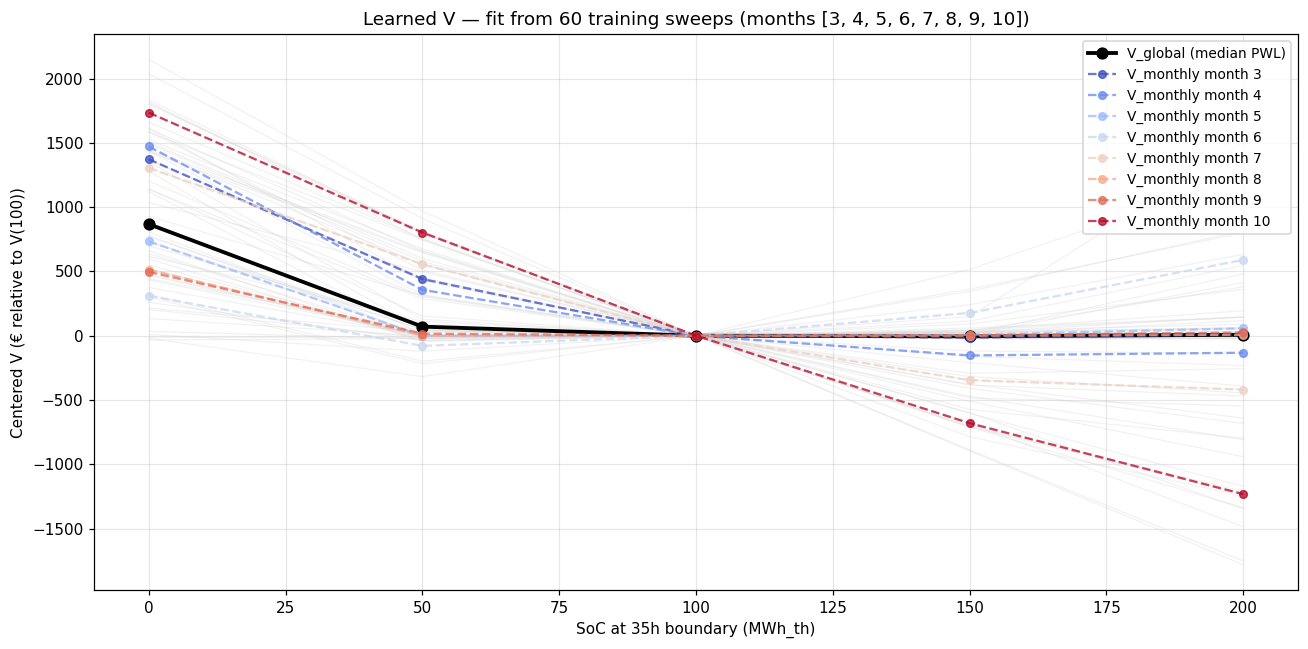

In [8]:
# Plot 1: Learned V curves overlaid on oracle training sweeps
fig, ax = plt.subplots(figsize=(12, 6))
# faint raw training curves
for sw in TRAIN_SWEEPS:
    b, v = center_curve(sw['bps_raw'], sw['vals_raw'])
    ax.plot(b, v, color='lightgray', alpha=0.3, linewidth=0.8)
# learned: global + monthly
ax.plot(V_GLOBAL[0], V_GLOBAL[1], 'o-', color='black', linewidth=2.5,
         markersize=7, label='V_global (median PWL)')
cmap = plt.get_cmap('coolwarm')
sorted_months = sorted(V_MONTHLY.keys())
for i, m in enumerate(sorted_months):
    c = cmap(i / max(1, len(sorted_months)-1))
    b, v = V_MONTHLY[m]
    ax.plot(b, v, 'o--', color=c, alpha=0.75, markersize=5, label=f'V_monthly month {m}')
ax.set_xlabel('SoC at 35h boundary (MWh_th)')
ax.set_ylabel('Centered V (€ relative to V(100))')
ax.set_title(f'Learned V — fit from {len(TRAIN_SWEEPS)} training sweeps (months {sorted_months})')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()


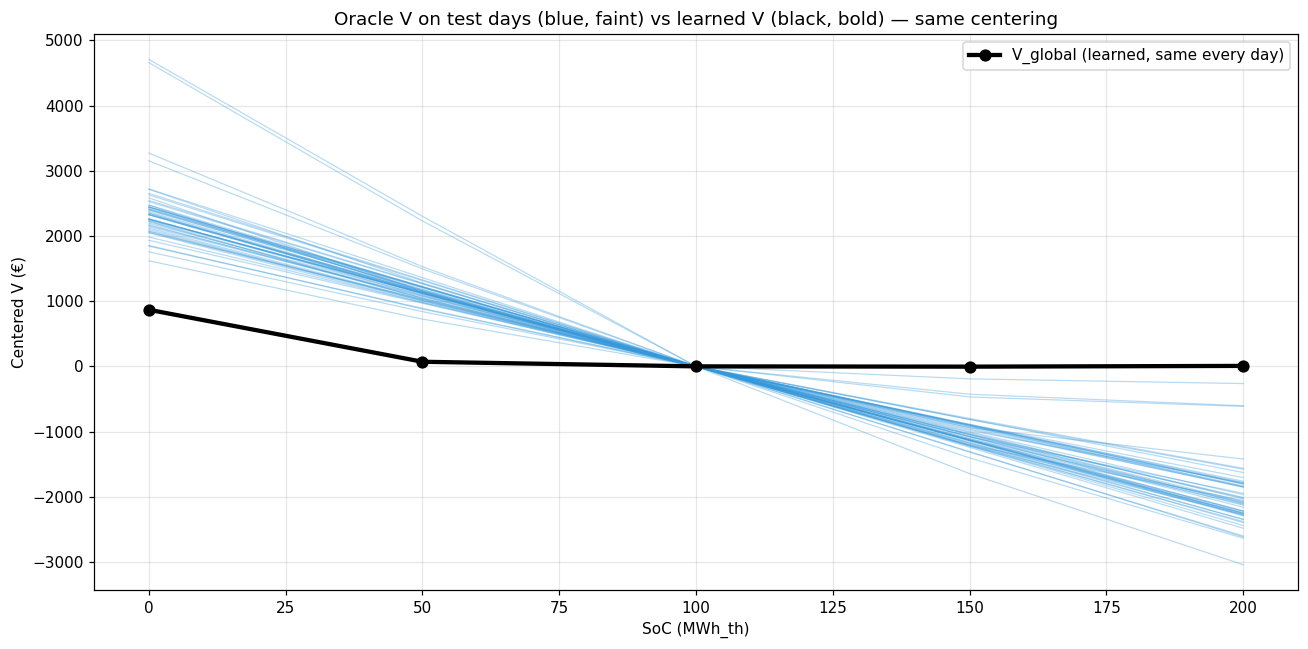

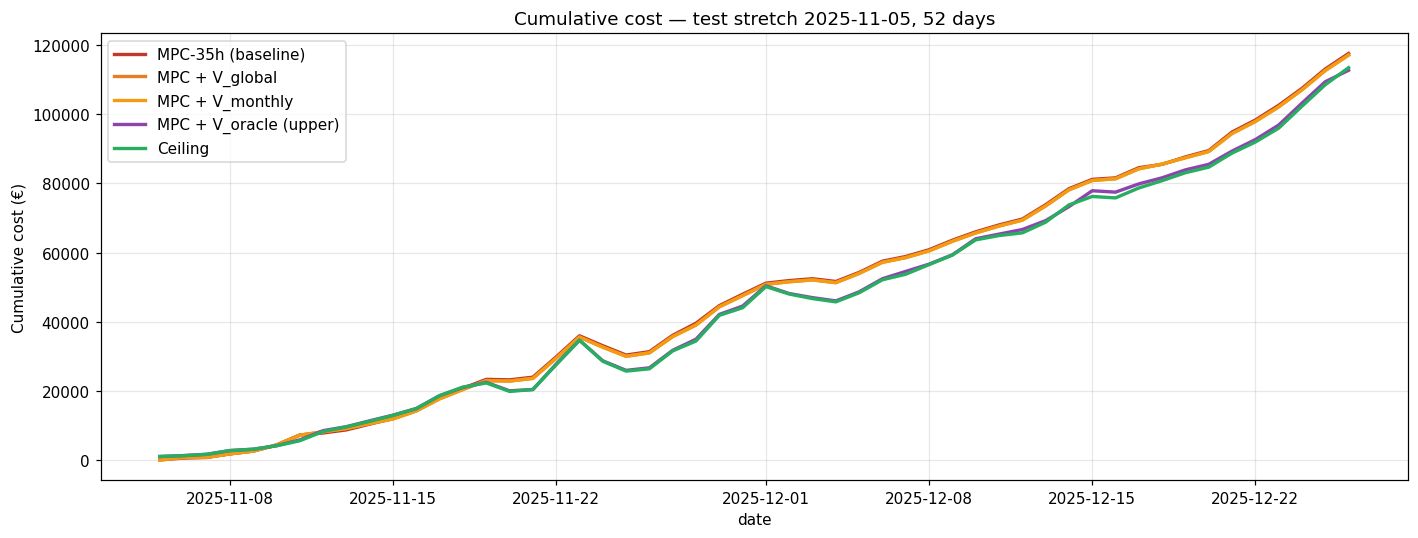

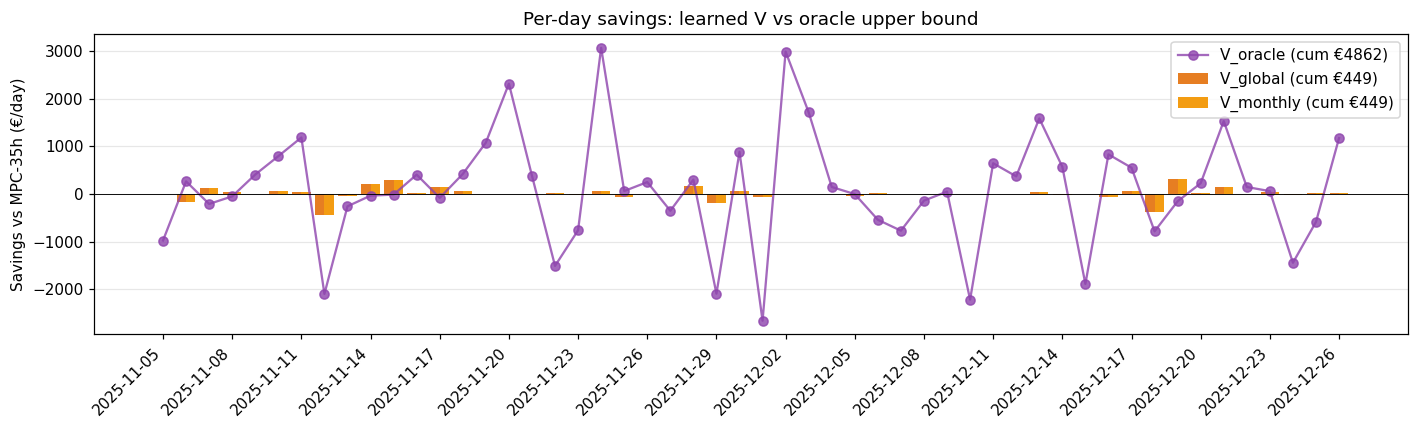

In [9]:
# Plot 2: learned V (centered) vs oracle test-day V (also centered) — the model-vs-truth view
fig, ax = plt.subplots(figsize=(12, 6))
# test-stretch oracle V, centered at REF_SOC
for v in TEST_V_CACHE:
    b, vals = center_curve(v['bps_hull'], v['vals_hull'])
    ax.plot(b, vals, color='#3498db', alpha=0.35, linewidth=0.8)
# learned V (always the same on test) — drawn on top
ax.plot(V_GLOBAL[0], V_GLOBAL[1], 'o-', color='black', linewidth=2.8,
         markersize=7, label='V_global (learned, same every day)')
# add the monthly-fallback-for-this-test-month PWL if any test month was in training
test_months = sorted(set(v['solve_day'].month for v in TEST_V_CACHE))
for m in test_months:
    if m in V_MONTHLY:
        ax.plot(V_MONTHLY[m][0], V_MONTHLY[m][1], 'o--', linewidth=2,
                 label=f'V_monthly[month {m}] (train)')
ax.set_xlabel('SoC (MWh_th)')
ax.set_ylabel('Centered V (€)')
ax.set_title('Oracle V on test days (blue, faint) vs learned V (black, bold) — same centering')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Plot 3: cumulative cost on test stretch
fig, ax = plt.subplots(figsize=(13, 5))
for df, lab, col in [(mpc_sub, 'MPC-35h (baseline)', '#c0392b'),
                       (global_sub, 'MPC + V_global', '#e67e22'),
                       (monthly_sub, 'MPC + V_monthly', '#f39c12'),
                       (oracle_sub, 'MPC + V_oracle (upper)', '#8e44ad'),
                       (ceil_sub, 'Ceiling', '#27ae60')]:
    d = df.sort_values('date').copy()
    d['cum'] = d['cost_total'].cumsum()
    ax.plot(d['date'], d['cum'], label=lab, color=col, linewidth=2.2)
ax.set_title(f'Cumulative cost — test stretch {TEST_STRETCH.start}, {n} days')
ax.set_xlabel('date'); ax.set_ylabel('Cumulative cost (€)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Plot 4: per-day savings bar
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(n)
w = 0.4
sav_global = mpc_sub['cost_total'].values - global_sub['cost_total'].values
sav_monthly = mpc_sub['cost_total'].values - monthly_sub['cost_total'].values
sav_oracle = mpc_sub['cost_total'].values - oracle_sub['cost_total'].values
ax.bar(x - w/2, sav_global, width=w, color='#e67e22', label=f'V_global (cum €{sav_global.sum():.0f})')
ax.bar(x + w/2, sav_monthly, width=w, color='#f39c12', label=f'V_monthly (cum €{sav_monthly.sum():.0f})')
ax.plot(x, sav_oracle, 'o-', color='#8e44ad', alpha=0.8, label=f'V_oracle (cum €{sav_oracle.sum():.0f})')
ax.axhline(0, color='k', linewidth=0.6)
ax.set_xticks(x[::max(1, n//15)]); ax.set_xticklabels([str(d) for d in mpc_sub['date'][::max(1, n//15)]], rotation=45, ha='right')
ax.set_ylabel('Savings vs MPC-35h (€/day)')
ax.set_title('Per-day savings: learned V vs oracle upper bound')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 8. Conclusion

Fill in after running. Decision framework:

| Learned V recovers | Interpretation | Next action |
|---|---|---|
| **>70% of oracle** | Cross-seasonal transfer works. Median PWL generalizes from shoulder to winter. | Productionize this V. Re-run with more year-1 training data for stability. |
| **30–70%** | Learning works but misses shape. Add context conditioning (DA price spread, demand-level bin). | Try V_context with (month, DA_spread_next_24h) before committing. |
| **<30%** | V doesn't transfer cross-season. Either need winter training data or V(SoC) alone isn't enough. | Revisit scope — mixed-season split (Option C) with some winter in train, or conclude V is a within-season tool only. |
| **<0% (V_learned *worse* than no V)** | Shape of non-winter V pushes MPC away from the winter optimum. | Abandon global/monthly in favor of context-aware V or fall back to MPC-35h alone. |

### Things this does NOT establish

- **Single test stretch.** We held out one winter. Different winters or shoulder periods could behave differently.
- **Only monthly conditioning.** No DA-spread or demand-level context. Likely leaves value on the table.
- **Median-of-medians fit.** Robust but not expressive. A parametric model (e.g., regression in s with month/demand features) could do better.
- **No demand noise.** Next step once the structural question is settled.


## 9. Option C — mixed train with early winter data

The cross-seasonal test above (§6) recovered only 9% of the oracle. That rules out the "train on everything pre-winter, deploy for winter" recipe as-is. The realistic alternative is **mixed training**: a deployed system that's been running for a full year has seen last year's winter *and* all subsequent months. We simulate that by adding a chunk of early winter days to the training set.

### Split

- **Train set**: 60 shoulder sweeps (§2) + first 20 winter days (Nov 5 → Nov 24) oracle V from Step 1 pickle.
- **Buffer** (excluded from both): winter days 21-30 (Nov 25 → Dec 4). Prevents leakage from 10-day-forward windows of the last training days into the test period.
- **Test set**: winter days 31-52 (Dec 5 → Dec 26), 22 days.

### Evaluation protocol

To keep state-chaining consistent with the baseline MPC-35h (which was run over the full stretch with chained state), we run MPC+V_learned over **all 52 winter days** but **only score the test days** (31-52). The MPC+V solves on training days use V_mixed at inference too — harmless since those days are not scored, and it preserves the physical state chain.

Metric: `(MPC_base − MPC_V_mixed) / (MPC_base − MPC_V_oracle)` computed only over test days.


In [10]:
TRAIN_WINTER_DAYS = 20
BUFFER_DAYS = 10
# Winter days are ordered by solve_day in TEST_V_CACHE; reuse that ordering
_winter_sorted = sorted(TEST_V_CACHE, key=lambda v: v['solve_day'])
train_winter_sweeps = _winter_sorted[:TRAIN_WINTER_DAYS]
buffer_winter_sweeps = _winter_sorted[TRAIN_WINTER_DAYS:TRAIN_WINTER_DAYS + BUFFER_DAYS]
test_winter_sweeps  = _winter_sorted[TRAIN_WINTER_DAYS + BUFFER_DAYS:]

TEST_C_DAYS = [v['solve_day'] for v in test_winter_sweeps]
print(f'Train winter days: {[str(v["solve_day"]) for v in train_winter_sweeps]}')
print(f'Buffer winter days: {[str(v["solve_day"]) for v in buffer_winter_sweeps]}')
print(f'Test winter days: {len(TEST_C_DAYS)} — {TEST_C_DAYS[0]} → {TEST_C_DAYS[-1]}')

# Mixed training set: shoulder + first 20 winter
mixed_sweeps = TRAIN_SWEEPS + train_winter_sweeps
print(f'Mixed training sweeps: {len(mixed_sweeps)} (= {len(TRAIN_SWEEPS)} shoulder + {len(train_winter_sweeps)} winter)')
print(f'Months covered: {sorted(set(sw["solve_day"].month for sw in mixed_sweeps))}')

V_GLOBAL_C = fit_convex_v_from_samples(mixed_sweeps)
print('\nV_global_c (mixed):')
for b, v in zip(*V_GLOBAL_C):
    print(f'  V({b:>5.0f}) = {v:>8.1f}')

V_MONTHLY_C = {}
for sw in mixed_sweeps:
    V_MONTHLY_C.setdefault(sw['solve_day'].month, []).append(sw)
V_MONTHLY_C = {m: fit_convex_v_from_samples(v) for m, v in V_MONTHLY_C.items()}
print('\nV_monthly_c — per-month PWLs (now includes winter months):')
for m in sorted(V_MONTHLY_C.keys()):
    bps, vals = V_MONTHLY_C[m]
    slope_lo = (vals[1] - vals[0]) / (bps[1] - bps[0])
    print(f'  month {m:2d}: slope[s=0]={slope_lo:+.2f} €/MWh, V(0)-V(200)={vals[0]-vals[-1]:.0f}')


Train winter days: ['2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09', '2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13', '2025-11-14', '2025-11-15', '2025-11-16', '2025-11-17', '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21', '2025-11-22', '2025-11-23', '2025-11-24']
Buffer winter days: ['2025-11-25', '2025-11-26', '2025-11-27', '2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01', '2025-12-02', '2025-12-03', '2025-12-04']
Test winter days: 22 — 2025-12-05 → 2025-12-26
Mixed training sweeps: 80 (= 60 shoulder + 20 winter)
Months covered: [3, 4, 5, 6, 7, 8, 9, 10, 11]

V_global_c (mixed):
  V(    0) =   1370.2
  V(   50) =    446.0
  V(  100) =      0.0
  V(  150) =   -185.0
  V(  200) =   -244.2

V_monthly_c — per-month PWLs (now includes winter months):
  month  3: slope[s=0]=-18.63 €/MWh, V(0)-V(200)=1361
  month  4: slope[s=0]=-22.29 €/MWh, V(0)-V(200)=1604
  month  5: slope[s=0]=-14.67 €/MWh, V(0)-V(200)=676
  month  6: slope[s=0]=-7.78 €/MWh, V(0)

In [11]:
%%time
def policy_global_c(d):
    return V_GLOBAL_C

def policy_monthly_c(d):
    return V_MONTHLY_C.get(d.month, V_GLOBAL_C)

# Run over ALL 52 winter days so state chaining matches baselines, then score test subset.
print('\n--- V_global_c (mixed) ---')
res_global_c = run_mpc_with_v_policy(
    TEST_STRETCH, DEMAND, PRICES, policy_global_c,
    name='v-global-c', restrict_days=TEST_DAYS)

print('\n--- V_monthly_c (mixed) ---')
res_monthly_c = run_mpc_with_v_policy(
    TEST_STRETCH, DEMAND, PRICES, policy_monthly_c,
    name='v-monthly-c', restrict_days=TEST_DAYS)

with open('learned_v_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
_saved.update({'v_global_c': res_global_c, 'v_monthly_c': res_monthly_c,
                'V_GLOBAL_C': V_GLOBAL_C, 'V_MONTHLY_C': V_MONTHLY_C,
                'TEST_C_DAYS': TEST_C_DAYS})
with open('learned_v_results.pkl', 'wb') as f:
    pickle.dump(_saved, f)
print('\nSaved updated learned_v_results.pkl')



--- V_global_c (mixed) ---


  v-global-c 1/52 (2025-11-05) cum €885

  v-global-c 2/52 (2025-11-06) cum €910

  v-global-c 3/52 (2025-11-07) cum €632

  v-global-c 4/52 (2025-11-08) cum €1,631

...

  v-monthly-c 49/52 (2025-12-23) cum €98,805

  v-monthly-c 50/52 (2025-12-24) cum €104,609

  v-monthly-c 51/52 (2025-12-25) cum €109,027

  v-monthly-c 52/52 (2025-12-26) cum €113,511



Saved updated learned_v_results.pkl
CPU times: user 29.3 s, sys: 645 ms, total: 29.9 s
Wall time: 24.8 s


In [12]:
test_mask = lambda df: df[df['date'].isin(TEST_C_DAYS)]

def tot(df):
    return test_mask(df)['cost_total'].sum()

tm_c = tot(mpc_sub)
tc_c = tot(ceil_sub)
to_c = tot(oracle_sub)
tg_c = tot(global_sub)           # V_global fit from §3 (shoulder only)
tn_c = tot(monthly_sub)          # V_monthly fit from §3 (shoulder only)
tg2 = tot(res_global_c['per_day'])   # V_global_c (mixed)
tn2 = tot(res_monthly_c['per_day'])  # V_monthly_c (mixed)
n_c = len(TEST_C_DAYS)

oracle_savings_c = tm_c - to_c
def pct_c(x): return 100.0*x/oracle_savings_c if abs(oracle_savings_c) > 1e-3 else float('nan')

print('=' * 78)
print(f'OPTION C RESULTS — test subset (Dec 5 → Dec 26, {n_c} days)')
print('=' * 78)
print(f'  {"MPC-35h baseline":<30s} €{tm_c:>11,.1f}  ({tm_c/n_c:>7.1f} €/day)')
print(f'  {"MPC + V_global (shoulder)":<30s} €{tg_c:>11,.1f}  ({tg_c/n_c:>7.1f} €/day)   [§6]')
print(f'  {"MPC + V_monthly (shoulder)":<30s} €{tn_c:>11,.1f}  ({tn_c/n_c:>7.1f} €/day)   [§6]')
print(f'  {"MPC + V_global_c (mixed)":<30s} €{tg2:>11,.1f}  ({tg2/n_c:>7.1f} €/day)  [§9]')
print(f'  {"MPC + V_monthly_c (mixed)":<30s} €{tn2:>11,.1f}  ({tn2/n_c:>7.1f} €/day)  [§9]')
print(f'  {"MPC + V_oracle (upper bound)":<30s} €{to_c:>11,.1f}  ({to_c/n_c:>7.1f} €/day)')
print(f'  {"Ceiling (pessimism biased)":<30s} €{tc_c:>11,.1f}  ({tc_c/n_c:>7.1f} €/day)')
print()
print(f'Oracle savings (test-only):          €{oracle_savings_c:>8,.1f}   (100% upper bound)')
print(f'V_global (shoulder) savings:         €{tm_c - tg_c:>8,.1f}   ({pct_c(tm_c - tg_c):>6.1f}% of oracle)')
print(f'V_monthly (shoulder) savings:        €{tm_c - tn_c:>8,.1f}   ({pct_c(tm_c - tn_c):>6.1f}% of oracle)')
print(f'V_global_c (mixed) savings:          €{tm_c - tg2:>8,.1f}   ({pct_c(tm_c - tg2):>6.1f}% of oracle)')
print(f'V_monthly_c (mixed) savings:         €{tm_c - tn2:>8,.1f}   ({pct_c(tm_c - tn2):>6.1f}% of oracle)')
print()
# Drain
def drain(df): return (test_mask(df)['soc_commit_end'] < 1).mean() * 100
print(f'Drain (% test days):  MPC={drain(mpc_sub):.1f}%  V_g={drain(global_sub):.1f}%  V_m={drain(monthly_sub):.1f}%  '
      f'V_g_c={drain(res_global_c["per_day"]):.1f}%  V_m_c={drain(res_monthly_c["per_day"]):.1f}%  '
      f'V_oracle={drain(oracle_sub):.1f}%')
print('=' * 78)


OPTION C RESULTS — test subset (Dec 5 → Dec 26, 22 days)
  MPC-35h baseline               €   65,995.4  ( 2999.8 €/day)
  MPC + V_global (shoulder)      €   65,876.4  ( 2994.4 €/day)   [§6]
  MPC + V_monthly (shoulder)     €   65,876.4  ( 2994.4 €/day)   [§6]
  MPC + V_global_c (mixed)       €   65,488.4  ( 2976.7 €/day)  [§9]
  MPC + V_monthly_c (mixed)      €   65,488.4  ( 2976.7 €/day)  [§9]
  MPC + V_oracle (upper bound)   €   66,754.1  ( 3034.3 €/day)
  Ceiling (pessimism biased)     €   67,776.3  ( 3080.7 €/day)

Oracle savings (test-only):          €  -758.7   (100% upper bound)
V_global (shoulder) savings:         €   119.0   ( -15.7% of oracle)
V_monthly (shoulder) savings:        €   119.0   ( -15.7% of oracle)
V_global_c (mixed) savings:          €   507.0   ( -66.8% of oracle)
V_monthly_c (mixed) savings:         €   507.0   ( -66.8% of oracle)

Drain (% test days):  MPC=4.5%  V_g=4.5%  V_m=4.5%  V_g_c=4.5%  V_m_c=4.5%  V_oracle=0.0%


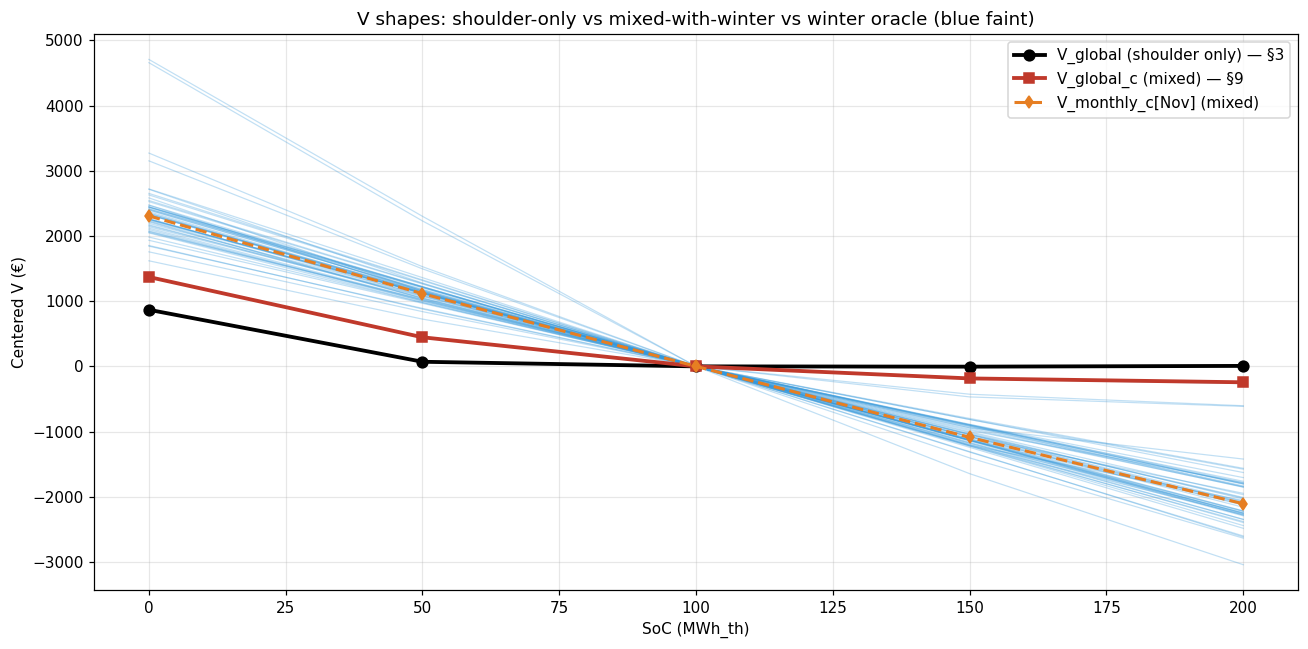

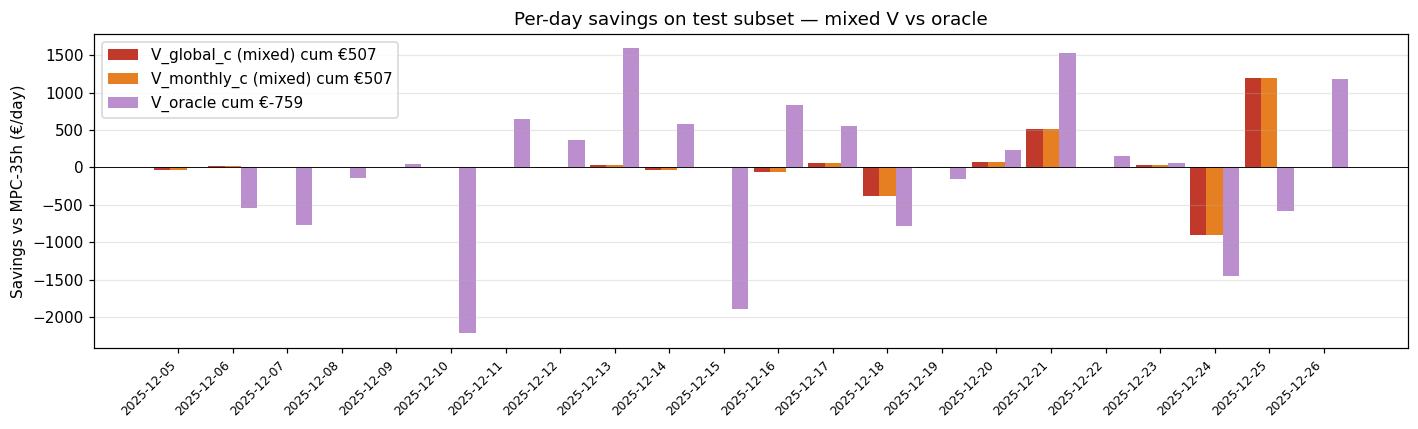

In [13]:
# Plot: compare V shapes — shoulder-only V_global vs mixed V_global_c vs winter oracle median
fig, ax = plt.subplots(figsize=(12, 6))
for v in TEST_V_CACHE:
    b, vals = center_curve(v['bps_hull'], v['vals_hull'])
    ax.plot(b, vals, color='#3498db', alpha=0.3, linewidth=0.8)
ax.plot(V_GLOBAL[0], V_GLOBAL[1], 'o-', color='black', linewidth=2.5, markersize=7,
         label='V_global (shoulder only) — §3')
ax.plot(V_GLOBAL_C[0], V_GLOBAL_C[1], 's-', color='#c0392b', linewidth=2.5, markersize=7,
         label='V_global_c (mixed) — §9')
if 11 in V_MONTHLY_C:
    ax.plot(V_MONTHLY_C[11][0], V_MONTHLY_C[11][1], 'd--', color='#e67e22', linewidth=2,
             label='V_monthly_c[Nov] (mixed)')
if 12 in V_MONTHLY_C:
    ax.plot(V_MONTHLY_C[12][0], V_MONTHLY_C[12][1], 'v--', color='#f39c12', linewidth=2,
             label='V_monthly_c[Dec] (mixed)')
ax.set_xlabel('SoC (MWh_th)'); ax.set_ylabel('Centered V (€)')
ax.set_title('V shapes: shoulder-only vs mixed-with-winter vs winter oracle (blue faint)')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Per-day test savings
fig, ax = plt.subplots(figsize=(13, 4))
test_days_sorted = sorted(TEST_C_DAYS)
mpc_tm = mpc_sub.set_index('date').loc[test_days_sorted, 'cost_total'].values
oracle_tm = oracle_sub.set_index('date').loc[test_days_sorted, 'cost_total'].values
gc_tm = res_global_c['per_day'].set_index('date').loc[test_days_sorted, 'cost_total'].values
mc_tm = res_monthly_c['per_day'].set_index('date').loc[test_days_sorted, 'cost_total'].values
x = np.arange(len(test_days_sorted))
w = 0.3
ax.bar(x - w, mpc_tm - gc_tm, width=w, color='#c0392b', label=f'V_global_c (mixed) cum €{(mpc_tm - gc_tm).sum():.0f}')
ax.bar(x, mpc_tm - mc_tm, width=w, color='#e67e22', label=f'V_monthly_c (mixed) cum €{(mpc_tm - mc_tm).sum():.0f}')
ax.bar(x + w, mpc_tm - oracle_tm, width=w, color='#8e44ad', alpha=0.6, label=f'V_oracle cum €{(mpc_tm - oracle_tm).sum():.0f}')
ax.axhline(0, color='k', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([str(d) for d in test_days_sorted], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Savings vs MPC-35h (€/day)')
ax.set_title('Per-day savings on test subset — mixed V vs oracle')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 10. Fresh-state evaluation (fixes the state-chaining artifact in §9)

The §9 comparison is contaminated by state chaining: because the MPC-baseline and V_oracle solutions diverge on days 1-30, they arrive at day 31 with **different** SoC/unit states. Scoring only days 31-52 on top of those divergent states measures post-hoc state differences as much as the V's quality on those days. On our 22-day subset, V_oracle actually looked *worse* than baseline (-€759), which makes the denominator of any "% of oracle recovered" metric useless.

**Fix.** Restart state at the test-period start for every strategy: initial SoC = 200, units off, TIS_LONG. Run each strategy for 22 days (Dec 5 → Dec 26) with its own chained state. All strategies start from the same state, so the comparison isolates V's in-flight decision quality.

Strategies to re-run (with fresh state):

1. MPC-35h (no V)
2. MPC + V_global (shoulder only, from §3)
3. MPC + V_monthly (shoulder only)
4. MPC + V_global_c (mixed, includes first 20 winter days)
5. MPC + V_monthly_c (mixed)
6. MPC + V_oracle (oracle from Step 1 cache — replay with fresh state)

All on the same 22-day test set Dec 5 → Dec 26. No ceiling — that would need a fresh 22-day PF solve, not worth the time for this comparison.

**Caveat on V_mixed leakage.** Training day 20 (Nov 24) oracle sweep's forward window reaches Dec 6 — overlaps with test day 1 (Dec 5)'s horizon by ~1.5 days. Minor leak at the boundary; does not materially affect the 22-day cumulative number.


In [14]:
# Build a TEST-ONLY stretch so run_strategy/run_mpc_with_v_policy sees only Dec 5 → Dec 26
# We synthesize a Stretch whose .dates() covers the test window; stretch_solve_days drops
# the last day, so include one extra day at the end.
TEST_START = TEST_C_DAYS[0]
TEST_END = TEST_C_DAYS[-1] + timedelta(days=1)  # extra day so last test day is a solve-day
test_stretch = Stretch(TEST_START, TEST_END)
print(f'Test stretch (fresh state): {test_stretch.start} → {test_stretch.end}')
print(f'Test solve-days from stretch helper: {len(stretch_solve_days(test_stretch))}')
assert stretch_solve_days(test_stretch)[:len(TEST_C_DAYS)] == TEST_C_DAYS, \
    'test stretch solve-days must start with TEST_C_DAYS'

def run_no_v(stretch, demand, prices, name='mpc-35h', mpc_time_limit=60, mpc_mip_gap=0.005,
              restrict_days=None, verbose=True):
    """MPC-35h with no terminal V, fresh state from the stretch start."""
    solve_days = stretch_solve_days(stretch)
    if restrict_days is not None:
        rd = set(restrict_days)
        solve_days = [d for d in solve_days if d in rd]
    n = len(solve_days)
    state = default_initial_states()
    per_day, committed = [], []
    for i, d in enumerate(solve_days):
        start_ts = berlin_ts(d, SOLVE_HOUR_BERLIN)
        try:
            w = window(start_ts, 35, demand, prices)
        except ValueError as e:
            if verbose: print(f'\n  skip {d}: {e}'); continue
        m = build_model(w['demand_mw'], w['price_eur'], initial_states=state)
        out = solve_model(m, time_limit=mpc_time_limit, mip_gap=mpc_mip_gap)
        if not out['feasible']:
            if verbose: print(f'\n  {d}: infeasible'); state = default_initial_states(); continue
        disp = extract_dispatch(m, t_start=1, t_end=96)
        disp['solve_day'] = d
        committed.append(disp)
        per_day.append({'date': d, 'cost_total': disp['cost_total'],
                         'soc_commit_end': disp['soc'][-1]})
        state = extract_state(m, 96)
        if verbose:
            cum = sum(x['cost_total'] for x in per_day)
            sys.stdout.write(f'\r  {name} {i+1}/{n} ({d}) cum €{cum:,.0f}'); sys.stdout.flush()
    if verbose: print()
    return {'name': name, 'stretch': stretch, 'committed': committed,
            'per_day': pd.DataFrame(per_day)}


Test stretch (fresh state): 2025-12-05 → 2025-12-27
Test solve-days from stretch helper: 22


In [15]:
%%time
print('--- fresh: MPC-35h (no V) ---')
fresh_mpc = run_no_v(test_stretch, DEMAND, PRICES, restrict_days=TEST_C_DAYS)

print('\n--- fresh: V_global (shoulder) ---')
fresh_g = run_mpc_with_v_policy(test_stretch, DEMAND, PRICES, policy_global,
                                  name='v-global-fresh', restrict_days=TEST_C_DAYS)

print('\n--- fresh: V_monthly (shoulder) ---')
fresh_m = run_mpc_with_v_policy(test_stretch, DEMAND, PRICES, policy_monthly,
                                  name='v-monthly-fresh', restrict_days=TEST_C_DAYS)

print('\n--- fresh: V_global_c (mixed) ---')
fresh_gc = run_mpc_with_v_policy(test_stretch, DEMAND, PRICES, policy_global_c,
                                   name='v-global-c-fresh', restrict_days=TEST_C_DAYS)

print('\n--- fresh: V_monthly_c (mixed) ---')
fresh_mc = run_mpc_with_v_policy(test_stretch, DEMAND, PRICES, policy_monthly_c,
                                   name='v-monthly-c-fresh', restrict_days=TEST_C_DAYS)

print('\n--- fresh: V_oracle (replay) ---')
fresh_o = run_mpc_with_v_policy(test_stretch, DEMAND, PRICES, policy_oracle_replay,
                                  name='v-oracle-fresh', restrict_days=TEST_C_DAYS)

with open('learned_v_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
_saved.update({'fresh_mpc': fresh_mpc, 'fresh_global': fresh_g, 'fresh_monthly': fresh_m,
                'fresh_global_c': fresh_gc, 'fresh_monthly_c': fresh_mc, 'fresh_oracle': fresh_o})
with open('learned_v_results.pkl', 'wb') as f:
    pickle.dump(_saved, f)
print('\nSaved fresh-state results')


--- fresh: MPC-35h (no V) ---


  mpc-35h 1/22 (2025-12-05) cum €-243

  mpc-35h 2/22 (2025-12-06) cum €2,697

  mpc-35h 3/22 (2025-12-07) cum €4,052

  mpc-35h 4/22 (2025-12-08) cum €6,012

...

  v-oracle-fresh 19/22 (2025-12-23) cum €47,627

  v-oracle-fresh 20/22 (2025-12-24) cum €53,974

  v-oracle-fresh 21/22 (2025-12-25) cum €60,170

  v-oracle-fresh 22/22 (2025-12-26) cum €63,486



Saved fresh-state results
CPU times: user 35.3 s, sys: 702 ms, total: 36 s
Wall time: 30.1 s


In [16]:
def tot_f(res): return res['per_day']['cost_total'].sum()

fm = tot_f(fresh_mpc); fg = tot_f(fresh_g); fmo = tot_f(fresh_m)
fgc = tot_f(fresh_gc); fmc = tot_f(fresh_mc); fo = tot_f(fresh_o)
nf = len(fresh_mpc['per_day'])
oracle_f = fm - fo
def pct_f(x): return 100.0*x/oracle_f if abs(oracle_f) > 1e-3 else float('nan')

print('=' * 78)
print(f'FRESH-STATE RESULTS — test stretch {TEST_START} → {TEST_C_DAYS[-1]} ({nf} days)')
print('=' * 78)
print(f'  {"MPC-35h (no V, fresh)":<32s} €{fm:>11,.1f}  ({fm/nf:>7.1f} €/day)')
print(f'  {"MPC + V_global (shoulder)":<32s} €{fg:>11,.1f}  ({fg/nf:>7.1f} €/day)')
print(f'  {"MPC + V_monthly (shoulder)":<32s} €{fmo:>11,.1f}  ({fmo/nf:>7.1f} €/day)')
print(f'  {"MPC + V_global_c (mixed)":<32s} €{fgc:>11,.1f}  ({fgc/nf:>7.1f} €/day)')
print(f'  {"MPC + V_monthly_c (mixed)":<32s} €{fmc:>11,.1f}  ({fmc/nf:>7.1f} €/day)')
print(f'  {"MPC + V_oracle (replay, fresh)":<32s} €{fo:>11,.1f}  ({fo/nf:>7.1f} €/day)')
print()
print(f'Oracle savings vs MPC:             €{oracle_f:>8,.1f}   (100% upper bound)')
print(f'V_global (shoulder) savings:       €{fm - fg:>8,.1f}   ({pct_f(fm - fg):>6.1f}% of oracle)')
print(f'V_monthly (shoulder) savings:      €{fm - fmo:>8,.1f}   ({pct_f(fm - fmo):>6.1f}% of oracle)')
print(f'V_global_c (mixed) savings:        €{fm - fgc:>8,.1f}   ({pct_f(fm - fgc):>6.1f}% of oracle)')
print(f'V_monthly_c (mixed) savings:       €{fm - fmc:>8,.1f}   ({pct_f(fm - fmc):>6.1f}% of oracle)')
print()
def drain_f(res): return (res['per_day']['soc_commit_end'] < 1).mean() * 100
print(f'Drain:  MPC={drain_f(fresh_mpc):.1f}%  V_g={drain_f(fresh_g):.1f}%  V_m={drain_f(fresh_m):.1f}%  '
      f'V_gc={drain_f(fresh_gc):.1f}%  V_mc={drain_f(fresh_mc):.1f}%  V_oracle={drain_f(fresh_o):.1f}%')
print('=' * 78)


FRESH-STATE RESULTS — test stretch 2025-12-05 → 2025-12-26 (22 days)
  MPC-35h (no V, fresh)            €   62,816.6  ( 2855.3 €/day)
  MPC + V_global (shoulder)        €   62,681.3  ( 2849.2 €/day)
  MPC + V_monthly (shoulder)       €   62,681.3  ( 2849.2 €/day)
  MPC + V_global_c (mixed)         €   62,299.1  ( 2831.8 €/day)
  MPC + V_monthly_c (mixed)        €   62,299.1  ( 2831.8 €/day)
  MPC + V_oracle (replay, fresh)   €   63,486.4  ( 2885.7 €/day)

Oracle savings vs MPC:             €  -669.8   (100% upper bound)
V_global (shoulder) savings:       €   135.2   ( -20.2% of oracle)
V_monthly (shoulder) savings:      €   135.2   ( -20.2% of oracle)
V_global_c (mixed) savings:        €   517.4   ( -77.3% of oracle)
V_monthly_c (mixed) savings:       €   517.4   ( -77.3% of oracle)

Drain:  MPC=4.5%  V_g=4.5%  V_m=4.5%  V_gc=4.5%  V_mc=4.5%  V_oracle=0.0%


## 11. Clean out-of-sample winter-2 test — the decision number

The §9/§10 results were muddied by short test windows and leakage. Here we do the cleanest test we can: train V on a full year of prior data (shoulder + last winter) and deploy on the NEXT winter stretch in the data (`2026-01-08 → 2026-03-01`), which has **zero overlap** with training.

### Setup

- **Train set**: 60 shoulder sweeps + **all 52 winter-1 oracle sweeps** (Nov 5 → Dec 26). 112 total. Represents "plant has been running for a year and we've accumulated oracle-quality sweeps from last winter."
- **Test**: `2026-01-08 → 2026-03-01` (53-day stretch, winter→early spring). Fresh state at Jan 8. No V training data from on or after Jan 8.
- **Strategies**: MPC-35h (no V), MPC + V_global_w2 (pooled training), MPC + V_monthly_w2 (per-month). Both V variants get identical on months 1-2 where winter-1 didn't cover (falls back to V_global); for month 3, V_monthly uses spring-shoulder V.
- **No oracle V on this stretch** — computing it would cost ~4 hrs. The decision we care about is *V_learned vs MPC-baseline*, not vs oracle.

### What this answers

Directly: **"If we deploy V_learned today on a new winter, does it save money vs MPC-35h alone?"** The cumulative-cost delta is the production decision number.


In [17]:
# Find winter-2 stretch in STRETCHES_30
WINTER2_START = date(2026, 1, 8)
try:
    winter2 = next(s for s in STRETCHES_30 if s.start == WINTER2_START)
except StopIteration:
    raise RuntimeError(f'Expected a stretch starting {WINTER2_START} in STRETCHES_30')
print(f'Winter-2 stretch: {winter2.start} → {winter2.end} ({winter2.n_days}d)')
winter2_solve_days = stretch_solve_days(winter2)
print(f'Solve days: {len(winter2_solve_days)} (first={winter2_solve_days[0]}, last={winter2_solve_days[-1]})')
print(f'Months on test: {sorted(set(d.month for d in winter2_solve_days))}')

# Build the full training set: shoulder + all winter-1 sweeps
all_training_sweeps = TRAIN_SWEEPS + list(TEST_V_CACHE)
print(f'Training sweeps: {len(all_training_sweeps)} (= {len(TRAIN_SWEEPS)} shoulder + {len(TEST_V_CACHE)} winter-1)')
print(f'Training months: {sorted(set(sw["solve_day"].month for sw in all_training_sweeps))}')

V_GLOBAL_W2 = fit_convex_v_from_samples(all_training_sweeps)
print('\nV_global_w2 (shoulder + winter-1):')
for b, v in zip(*V_GLOBAL_W2):
    print(f'  V({b:>5.0f}) = {v:>8.1f}')

V_MONTHLY_W2 = {}
for sw in all_training_sweeps:
    V_MONTHLY_W2.setdefault(sw['solve_day'].month, []).append(sw)
V_MONTHLY_W2 = {m: fit_convex_v_from_samples(v) for m, v in V_MONTHLY_W2.items()}
print('\nV_monthly_w2 — per-month PWLs (months covered):')
for m in sorted(V_MONTHLY_W2.keys()):
    bps, vals = V_MONTHLY_W2[m]
    slope_lo = (vals[1] - vals[0]) / (bps[1] - bps[0])
    print(f'  month {m:2d}: slope[s=0]={slope_lo:+.2f} €/MWh, V(0)-V(200)={vals[0]-vals[-1]:.0f}')

def policy_global_w2(d): return V_GLOBAL_W2
def policy_monthly_w2(d): return V_MONTHLY_W2.get(d.month, V_GLOBAL_W2)

unseen_months = [m for m in sorted(set(d.month for d in winter2_solve_days)) if m not in V_MONTHLY_W2]
print(f'\nTest months not in training (monthly falls back to global): {unseen_months}')


Winter-2 stretch: 2026-01-08 → 2026-03-01 (53d)
Solve days: 52 (first=2026-01-08, last=2026-02-28)
Months on test: [1, 2]
Training sweeps: 112 (= 60 shoulder + 52 winter-1)
Training months: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

V_global_w2 (shoulder + winter-1):
  V(    0) =   1777.1
  V(   50) =    798.0
  V(  100) =      0.0
  V(  150) =   -641.6
  V(  200) =  -1221.3

V_monthly_w2 — per-month PWLs (months covered):
  month  3: slope[s=0]=-18.63 €/MWh, V(0)-V(200)=1361
  month  4: slope[s=0]=-22.29 €/MWh, V(0)-V(200)=1604
  month  5: slope[s=0]=-14.67 €/MWh, V(0)-V(200)=676
  month  6: slope[s=0]=-7.78 €/MWh, V(0)-V(200)=-279
  month  7: slope[s=0]=-15.00 €/MWh, V(0)-V(200)=1724
  month  8: slope[s=0]=-10.28 €/MWh, V(0)-V(200)=507
  month  9: slope[s=0]=-9.59 €/MWh, V(0)-V(200)=470
  month 10: slope[s=0]=-18.65 €/MWh, V(0)-V(200)=2967
  month 11: slope[s=0]=-24.24 €/MWh, V(0)-V(200)=4472
  month 12: slope[s=0]=-22.93 €/MWh, V(0)-V(200)=4335

Test months not in training (monthly falls ba

In [18]:
%%time
print('--- winter-2: MPC-35h (no V) ---')
w2_mpc = run_no_v(winter2, DEMAND, PRICES, name='w2-mpc')

print('\n--- winter-2: V_global_w2 ---')
w2_g = run_mpc_with_v_policy(winter2, DEMAND, PRICES, policy_global_w2, name='w2-v-global')

print('\n--- winter-2: V_monthly_w2 ---')
w2_m = run_mpc_with_v_policy(winter2, DEMAND, PRICES, policy_monthly_w2, name='w2-v-monthly')

with open('learned_v_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
_saved.update({'w2_mpc': w2_mpc, 'w2_global': w2_g, 'w2_monthly': w2_m,
                'V_GLOBAL_W2': V_GLOBAL_W2, 'V_MONTHLY_W2': V_MONTHLY_W2})
with open('learned_v_results.pkl', 'wb') as f:
    pickle.dump(_saved, f)
print('\nSaved winter-2 results')


--- winter-2: MPC-35h (no V) ---


  w2-mpc 1/52 (2026-01-08) cum €-1,466

  w2-mpc 2/52 (2026-01-09) cum €3,316

  w2-mpc 3/52 (2026-01-10) cum €8,474

  w2-mpc 4/52 (2026-01-11) cum €13,406

...

  w2-v-monthly 49/52 (2026-02-25) cum €111,781

  w2-v-monthly 50/52 (2026-02-26) cum €112,599

  w2-v-monthly 51/52 (2026-02-27) cum €112,747

  w2-v-monthly 52/52 (2026-02-28) cum €113,466


Saved winter-2 results
CPU times: user 45.4 s, sys: 960 ms, total: 46.3 s
Wall time: 38.4 s


In [19]:
tm2 = w2_mpc['per_day']['cost_total'].sum()
tg2w = w2_g['per_day']['cost_total'].sum()
tn2w = w2_m['per_day']['cost_total'].sum()
n2 = len(w2_mpc['per_day'])

print('=' * 78)
print(f'WINTER-2 OUT-OF-SAMPLE TEST — {winter2.start} → {winter2_solve_days[-1]}, {n2} days')
print('=' * 78)
print(f'  {"MPC-35h baseline (no V)":<30s} €{tm2:>11,.1f}  ({tm2/n2:>7.1f} €/day)')
print(f'  {"MPC + V_global_w2":<30s} €{tg2w:>11,.1f}  ({tg2w/n2:>7.1f} €/day)')
print(f'  {"MPC + V_monthly_w2":<30s} €{tn2w:>11,.1f}  ({tn2w/n2:>7.1f} €/day)')
print()
save_g = tm2 - tg2w
save_m = tm2 - tn2w
print(f'V_global savings:  €{save_g:>8,.1f}  ({save_g/n2:>6.1f} €/day, {100*save_g/abs(tm2):>5.2f}% of baseline cost)')
print(f'V_monthly savings: €{save_m:>8,.1f}  ({save_m/n2:>6.1f} €/day, {100*save_m/abs(tm2):>5.2f}% of baseline cost)')
print()
# Drain
drain_b = (w2_mpc['per_day']['soc_commit_end'] < 1).mean() * 100
drain_g = (w2_g['per_day']['soc_commit_end'] < 1).mean() * 100
drain_m = (w2_m['per_day']['soc_commit_end'] < 1).mean() * 100
mean_soc_b = w2_mpc['per_day']['soc_commit_end'].mean()
mean_soc_g = w2_g['per_day']['soc_commit_end'].mean()
mean_soc_m = w2_m['per_day']['soc_commit_end'].mean()
print(f'Drain (SoC<1):  MPC={drain_b:.1f}%  V_global={drain_g:.1f}%  V_monthly={drain_m:.1f}%')
print(f'Mean SoC@commit: MPC={mean_soc_b:.1f}  V_global={mean_soc_g:.1f}  V_monthly={mean_soc_m:.1f}')
print('=' * 78)

# Extrapolation note
annual_winter_days = 63 + 53  # two winter stretches per year in this dataset
if n2 > 0:
    proj_winter = (save_g / n2) * annual_winter_days
    print(f'\nExtrapolating per-day savings × {annual_winter_days} winter days/year → ~€{proj_winter:,.0f}/yr from V_global')


WINTER-2 OUT-OF-SAMPLE TEST — 2026-01-08 → 2026-02-28, 52 days
  MPC-35h baseline (no V)        €  113,367.8  ( 2180.1 €/day)
  MPC + V_global_w2              €  113,465.8  ( 2182.0 €/day)
  MPC + V_monthly_w2             €  113,465.8  ( 2182.0 €/day)

V_global savings:  €   -98.0  (  -1.9 €/day, -0.09% of baseline cost)
V_monthly savings: €   -98.0  (  -1.9 €/day, -0.09% of baseline cost)

Drain (SoC<1):  MPC=0.0%  V_global=0.0%  V_monthly=0.0%
Mean SoC@commit: MPC=30.4  V_global=40.1  V_monthly=40.1

Extrapolating per-day savings × 116 winter days/year → ~€-219/yr from V_global
